In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.sparse import csr_matrix

%matplotlib inline

<Axes: xlabel='book_id', ylabel='average_rating'>

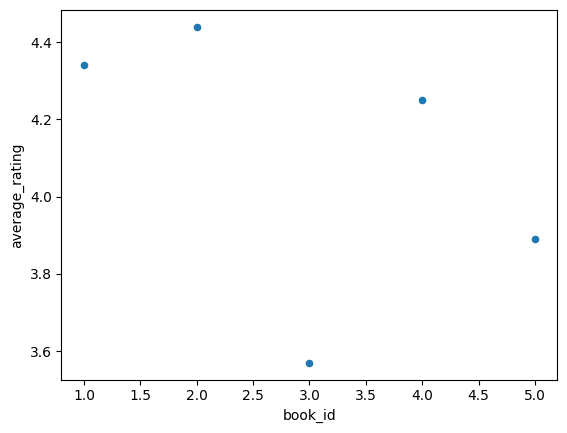

In [2]:
# cell for exploring book utilities...
book_url = "https://github.com/zygmuntz/goodbooks-10k/raw/master/books.csv"
b = pd.read_csv(book_url)
# b.head()
# b.shape
# b[(b["ratings_count"] > 10) & (b["average_rating"] > 3)]
clean_books = b[["book_id", "average_rating"]]
limited_books = clean_books.head(5)
limited_books.plot(kind = "scatter", x = "book_id", y = "average_rating")

# ax = plt.gca()
# ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# plt.show()


In [3]:
b

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7130616,7130616,7392860,19,441019455,9.780441e+12,Ilona Andrews,2010.0,Bayou Moon,...,17204,18856,1180,105,575,3538,7860,6778,https://images.gr-assets.com/books/1307445460m...,https://images.gr-assets.com/books/1307445460s...
9996,9997,208324,208324,1084709,19,067973371X,9.780680e+12,Robert A. Caro,1990.0,Means of Ascent,...,12582,12952,395,303,551,1737,3389,6972,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
9997,9998,77431,77431,2393986,60,039330762X,9.780393e+12,Patrick O'Brian,1977.0,The Mauritius Command,...,9421,10733,374,11,111,1191,4240,5180,https://images.gr-assets.com/books/1455373531m...,https://images.gr-assets.com/books/1455373531s...
9998,9999,8565083,8565083,13433613,7,61711527,9.780062e+12,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,...,11279,11994,1988,275,1002,3765,4577,2375,https://images.gr-assets.com/books/1279214118m...,https://images.gr-assets.com/books/1279214118s...


In [4]:
# cell for exploring rating utilities...

ratings_url = "https://github.com/zygmuntz/goodbooks-10k/raw/master/ratings.csv"
r = pd.read_csv(ratings_url)
r.isnull().sum()

print(r.shape)
# filter out users that have made less than 5 reviews and books that have less than 10 reviews
user_counts = r["user_id"].value_counts()
book_counts = r["book_id"].value_counts()

cleaned_ratings = r[
    (r["user_id"].map(user_counts) >= 5) &
     (r["book_id"].map(book_counts) >= 10)
      ]

"""
    1. Check for dupe rows (don't think this is needed)
    2. Check rating scales (no numbers <= 0 or >= 6)
    3. Check data types are correct
    4. Normalize (idk what this means tbh)
"""


cleaned_ratings
# r.shape

(5976479, 3)


,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3
...,...,...,...
5976474,49925,510,5
5976475,49925,528,4
5976476,49925,722,4
5976477,49925,949,5


In [5]:
"""
    start building user-item matrix
    r = users
    c = books
    cell = rating
"""

user_item_matrix = cleaned_ratings.pivot_table(
    index = "user_id",
    columns = "book_id",
    values = "rating"
)

# user_item_matrix.shape

# figure out how sparse matrix is (how many cells aren't filled in)
# total_cells = 53424 * 9999
# missing_cells = user_item_matrix.isnull().sum().sum()

# sparsity = missing_cells / total_cells * 100
# print(f"Matrix is {sparsity:.2f}% sparse")
# Answer: 98.88% sparse

# Now we fill in all the unfilled rows with the average rating that the user has left behind
user_item_matrix_filled = user_item_matrix.fillna(0)

user_item_sparse = csr_matrix(user_item_matrix_filled)
print(user_item_sparse.shape)
print(user_item_sparse.nnz)


(53424, 9999)
5976471
